## Importación de librerías


In [2]:
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import geopandas as gpd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Clustering
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# DuckDB, librería de lectura SQL optimizada, para agilizar la transformación de variables
import duckdb as ddb

# NuestrasFunciones, repertorio de fórmulas compartido por el profesor Guillermo Villarino en la asignatura Minería de datos y Modelización predictiva
from Formulas.NuestrasFuncionesRed import scree_plot_kmeans

import Formulas.FuncionesPropias as propias

In [3]:
# Datasets trabajados en el cuaderno anterior
Municipios = pd.read_csv('Datos procesados/MunicipiosGeo.csv', sep=';', encoding='UTF-8')
ProvinciasGeo = pd.read_csv('Datos procesados/ProvinciasGeo.csv', sep=';', encoding='UTF-8')
PuntosTuristicos = pd.read_csv('Datos procesados/PuntosTuristicos.csv', sep=';', encoding='UTF-8')

# Datos extraidos de la API, que no necesitaron limpieza de datos en el cuaderno anterior
OfertaProv = pd.read_csv('Extractor/data/processed/eoh_oferta_provincias.csv', sep=',', encoding='UTF-8')
OfertaRural = pd.read_csv('Extractor/data/processed/rural_oferta_provincias.csv', sep=',', encoding='UTF-8')
DemandaRural = pd.read_csv('Extractor/data/processed/rural_demanda_provincias.csv', sep=',', encoding='UTF-8')

# Oferta de OpenStreetMap, que no requiere de limpieza. Archivo parquet ya que contiene muchas más filas
OfertaOSM = pd.read_parquet("Datos procesados/pois_espana_osm.parquet")

# Mapa de municipios. 
# Agradecimientos al profesor Lorenzo Escot por adjuntar este mapa dentro del temario de "Minería de datos y modelización predictiva"
Map_muni = gpd.read_file('cartografias/Munic04_ESP.shp')

En primer lugar, vamos a revisar los tres dataframes extraidos directamente de la API.

En el caso de `OfertaOSM`, tabla con 170.000 registros, nos dará dos utilidades muy diferenciadoras. 

En primer lugar, al realizar agrupaciones por provincias tendremos los POIs (_Points Of Interest_) diferenciados en su categoría y subtipo, aunque por simplificar emplearemos unicamente la categoria (Para un trabajo empresarial son datos a tener en cuenta). Cabe mencionar que tambien es posible extraer desde la API el teléfono y pagina web (si hubiera) de cada uno de estos puntos.

En segundo lugar, al elaborar el dashboard porder aprovechar la columna de geometry para localizar todos estos puntos puede ser muy provechoso.

In [4]:
print(f'filas y columnas de OfertaOSM: {OfertaOSM.shape}')
print(' ')
OfertaOSM.head()

filas y columnas de OfertaOSM: (170939, 14)
 


,osm_id,osm_type,categoria,subtipo,nombre,cod_prov,provincia,latitud,longitud,estrellas,capacidad,municipio,codigo_postal,geometry_wkt
0,101331675,node,Ocio y Naturaleza,attraction,Sorginetxe trikuharria,01,Araba/Álava,42.829550,-2.378238,NaN,NaN,NaN,NaN,POINT (-2.378238 42.82955)
1,257921865,node,Alojamiento,hotel,400,01,Araba/Álava,42.842796,-2.670601,NaN,NaN,NaN,NaN,POINT (-2.670601 42.842796)
2,315898522,node,Restauracion,restaurant,Urtegi-alde,01,Araba/Álava,42.953143,-2.650224,NaN,NaN,NaN,NaN,POINT (-2.650224 42.953143)
3,392302250,node,Alojamiento,hotel,Dato,01,Araba/Álava,42.843640,-2.672684,2,14,NaN,NaN,POINT (-2.672684 42.84364)
4,392302251,node,Alojamiento,hotel,abba Jazz Hotel,01,Araba/Álava,42.843579,-2.675009,3,NaN,Vitoria-Gasteiz,01005,POINT (-2.675009 42.843579)


Agrupamos ``OfertaOSM`` por ``categoria``

In [5]:
OfertaOSM = OfertaOSM.pivot_table(
    index=['cod_prov', 'provincia'],
    columns='categoria',
    values='osm_id',
    aggfunc='count',
    fill_value=0
).reset_index()

OfertaOSM.columns = OfertaOSM.columns.str.replace({'Cultura y Patrimonio':'Cultura',
                                                   'Ocio y Naturaleza': 'Ocio'
                                                   })


In [6]:
OfertaOSM.head()

categoria,cod_prov,provincia,Alojamiento,Cultura,Ocio,Restauracion,Servicios Turisticos,Turismo General
0,01,Araba/Álava,136,137,165,1033,5,0
1,02,Albacete,202,90,146,649,0,0
2,03,Alicante/Alacant,727,430,498,5145,10,0
3,04,Almería,307,188,247,1388,7,0
4,05,Ávila,246,106,127,437,7,0


In [7]:
OfertaProv.head()

,COD_PROV,PROVINCIA,Anyo,Periodo,establecimientos_abiertos,grado_ocupacion_finsemana,grado_ocupacion_habitaciones,grado_ocupacion_plazas,plazas_estimadas,_meta.fecha_extraccion
0,1,Araba/Álava,2024,M08,70.0,74.09,80.43,73.98,4946.0,2026-09-14T13:39:16.852415
1,1,Araba/Álava,2024,M09,74.0,72.52,74.60,62.08,5260.0,2026-09-14T13:39:16.852415
2,1,Araba/Álava,2024,M10,74.0,63.26,67.32,54.80,5260.0,2026-09-14T13:39:16.852415
3,1,Araba/Álava,2024,M11,75.0,60.02,63.12,49.68,5335.0,2026-09-14T13:39:16.852415
4,1,Araba/Álava,2024,M12,74.0,59.92,57.18,48.03,5285.0,2026-09-14T13:39:16.852415


Como los dataframes no trabajados anteriormente poseen un eje temporal de 24 meses, debemos quedarnos con los ultimos 12 meses, por lo que usaremos la formula propia de ``crear_fecha()``, y despues filtraremos por los ultimos meses.

In [8]:
#Creamos la fecha para filtrar
OfertaProv = propias.crear_fecha(OfertaProv)
OfertaRural = propias.crear_fecha(OfertaRural)
DemandaRural = propias.crear_fecha(DemandaRural)


fecha_corte = OfertaProv['Fecha'].max() - pd.DateOffset(months=11) # Como los tres df contienen los mismos meses, esta variable nos servirá para los tres

OfertaProv = OfertaProv[OfertaProv['Fecha'] >= fecha_corte].reset_index(drop=True)
OfertaRural = OfertaRural[OfertaRural['Fecha'] >= fecha_corte].reset_index(drop=True)
DemandaRural= DemandaRural[DemandaRural['Fecha'] >= fecha_corte].reset_index(drop=True)

print(f"""COMPROBACION:
      La fecha de corte es: {fecha_corte}
      La fecha mas reciente es {OfertaProv['Fecha'].max()}
      La fecha mas antigua tras filtrar es {OfertaProv['Fecha'].min()}""")


COMPROBACION:
      La fecha de corte es: 2025-08-01 00:00:00
      La fecha mas reciente es 2026-07-01 00:00:00
      La fecha mas antigua tras filtrar es 2025-08-01 00:00:00


In [9]:
OfertaProv.describe().round(2)

,COD_PROV,Anyo,establecimientos_abiertos,grado_ocupacion_finsemana,grado_ocupacion_habitaciones,grado_ocupacion_plazas,plazas_estimadas,Fecha
count,624.00,624.00,624.00,624.00,624.00,624.00,624.00,624
mean,26.50,2025.58,286.52,55.11,55.73,46.75,30795.41,2026-01-15 10:00:00
min,1.00,2025.00,6.00,20.33,22.47,17.63,536.00,2025-08-01 00:00:00
25%,13.75,2025.00,138.00,45.06,43.46,35.38,6733.50,2025-10-24 06:00:00
50%,26.50,2026.00,197.50,54.98,53.92,44.32,11532.50,2026-01-16 12:00:00
75%,39.25,2026.00,341.25,65.08,66.78,56.14,28298.50,2026-04-08 12:00:00
max,52.00,2026.00,1381.00,88.69,91.66,89.61,379728.00,2026-07-01 00:00:00
std,15.02,0.49,259.66,13.42,15.42,14.61,50155.60,NaN


In [10]:
OfertaRural.describe().round(2)

,COD_PROV,Anyo,establecimientos_abiertos,grado_ocupacion_finsemana,grado_ocupacion_habitaciones,grado_ocupacion_plazas,plazas_estimadas,Fecha
count,600.00,600.00,600.00,600.00,600.00,600.00,600.00,600
mean,25.50,2025.58,329.98,33.24,26.26,19.75,3304.14,2026-01-15 10:00:00
min,1.00,2025.00,34.00,7.60,3.77,3.15,476.00,2025-08-01 00:00:00
25%,13.00,2025.00,158.00,25.69,17.52,12.74,1615.75,2025-10-24 06:00:00
50%,25.50,2026.00,241.00,32.62,22.84,16.90,2632.00,2026-01-16 12:00:00
75%,38.00,2026.00,430.75,39.32,30.12,22.94,4155.25,2026-04-08 12:00:00
max,50.00,2026.00,1634.00,69.66,82.83,73.08,15427.00,2026-07-01 00:00:00
std,14.44,0.49,254.16,10.90,13.57,11.19,2443.59,NaN


In [11]:
DemandaRural.describe().round(2)

,COD_PROV,Anyo,pernoctaciones,viajeros,Fecha
count,600.00,600.00,600.00,600.00,600
mean,25.50,2025.58,15208.70,6156.37,2026-01-15 10:00:00
min,1.00,2025.00,687.00,409.00,2025-08-01 00:00:00
25%,13.00,2025.00,5868.00,2646.50,2025-10-24 06:00:00
50%,25.50,2026.00,10306.50,4347.00,2026-01-16 12:00:00
75%,38.00,2026.00,19367.00,8321.25,2026-04-08 12:00:00
max,50.00,2026.00,223120.00,51928.00,2026-07-01 00:00:00
std,14.44,0.49,18169.82,5613.67,NaN


Tras revisar estos datos podemos determinar que estas tres tablas nos dan información muy relevante para construir la imagen referente a la oferta y demanda turística a nivel provincial, estimadores muy necesarios para medir la saturación y madurez de cada zona

Respecto a los puntos turísticos, analizados en el notebook anterior, podemos determinar que se miden a nivel municipal, centrandose en 104 municipios con una alta madurez turística, quedando pendiente su nivel de saturación. 

In [12]:
PuntosTuristicos.head()

,COD_INE,LOCALIDAD,VALOR PERNOCTACIONES EXTRANJERO,VALOR PERNOCTACIONES NACIONAL,VALOR VIAJERO EXTRANJERO,VALOR VIAJERO NACIONAL,PERIODO PERNOCTACIONES EXTRANJERO,PERIODO PERNOCTACIONES NACIONAL,PERIODO VIAJERO EXTRANJERO,PERIODO VIAJERO NACIONAL
0,3018,Altea,365608.0,291281.0,109312.0,136312.0,M09,M08,M05,M08
1,4032,Carboneras,9895.0,109766.0,4273.0,46406.0,M09,M08,M09,M07
2,4902,"Ejido, El",25776.0,52671.0,7614.0,18840.0,M08,M08,M08,M08
3,7003,Alcúdia,7562818.0,365652.0,1177676.0,88693.0,M08,M09,M08,M09
4,7015,Ciutadella de Menorca,3700172.0,709456.0,567668.0,165448.0,M08,M08,M08,M08


A continuación, tendremos que definir bien el tipo de dato de nuestros datos, comenzaremos con una revisión del tipo de dato

In [13]:
Columnas = ['COD_PROV', 'cod_ine', 'CODINE_MU']
Map_muni[Columnas] = Map_muni[Columnas].astype('Int64')

In [14]:
Map_prov = Map_muni[['COD_PROV', 'PROV','CCAA', 'geometry']].dissolve(by='COD_PROV', as_index=False) #Comprimimos el mapa por provincia

Map_prov.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   COD_PROV  52 non-null     Int64   
 1   geometry  52 non-null     geometry
 2   PROV      52 non-null     str     
 3   CCAA      52 non-null     str     
dtypes: Int64(1), geometry(1), str(2)
memory usage: 2.9 KB


Comprobamos que `cod_ine` y `CODINE_MU` contienen los mismos valores. si la siguiente celda muestra como resultado 0, entonces todas serán idénticas

In [15]:
# Comprobamos
print( f'Número de valores diferentes en variables mencionadas: {Map_muni[Map_muni['cod_ine'] != Map_muni['CODINE_MU']].shape[0]}')

Número de valores diferentes en variables mencionadas: 0


Al validar que son el mismo dato, la incluimos en la lista de variables que queremos eliminar para ahorrar memoria y simplificar

In [16]:
Map_muni = Map_muni.drop(columns= ['PROV','CCAA',
                                   'SP_ID','id',
                                   'POB_2016','POB_HO',
                                   'POB_MU','PARO_TO',
                                   'POB16_64','TASA_PARO',
                                   'RENTPCAP07', 'PrecioIn16']) # Eliminamos columnas que para este proyecto no son de interés
Map_muni.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 8108 entries, 0 to 8107
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   cod_ine    8108 non-null   Int64   
 1   CODINE_MU  8108 non-null   Int64   
 2   COD_PROV   8108 non-null   Int64   
 3   MUN        8108 non-null   str     
 4   geometry   8108 non-null   geometry
dtypes: Int64(3), geometry(1), str(1)
memory usage: 440.0 KB


In [17]:
ProvinciasGeo.head()

,COD_PROV,PROVINCIA,COD_CA,COMUNIDAD_AUTONOMA,CAPITAL,Perc_Provincia,Perc_VALOR PERNOCTACIONES,Perc_VALOR VIAJERO,Perc_PERIODO PERNOCTACIONES,Perc_PERIODO VIAJERO,...,cod_prov,Metricas_provincia,Metricas_poblacion,Metricas_total_viajeros,Metricas_media_mensual_viajeros,Metricas_std_mensual_viajeros,Metricas_presion_turistica,Metricas_indice_estacionalidad,Metricas_n_meses,Metricas__meta.fecha_extraccion
0,1,Araba/Álava,16,País Vasco/Euskadi,Vitoria-Gasteiz,Alava,2208517.0,1027118.0,M08,M08,...,1,Araba/Álava,333626.0,495295.0,41274.583333,8518.068085,1.484582,0.206376,12,2026-09-06T23:46:39.776749
1,2,Albacete,8,Castilla-La Mancha,Albacete,Albacete,1737927.0,842801.0,M09,M09,...,2,Albacete,386464.0,409581.0,34131.750000,6452.276795,1.059817,0.189040,12,2026-09-06T23:46:39.776749
2,3,Alacant/Alicante,10,Comunitat Valenciana,Alacant/Alicante,Alicante,37680371.0,10134012.0,M08,M08,...,3,Alicante/Alacant,1881762.0,5100916.0,425076.333333,112189.627548,2.710713,0.263928,12,2026-09-06T23:46:39.776749
3,4,Almería,1,Andalucía,Almería,Almería,10606166.0,3125996.0,M08,M08,...,4,Almería,731792.0,1585364.0,132113.666667,81085.945400,2.166413,0.613759,12,2026-09-06T23:46:39.776749
4,5,Ávila,7,Castilla y León,Ávila,Avila,1243810.0,781100.0,M08,M08,...,5,Ávila,158421.0,394330.0,32860.833333,6580.058135,2.489127,0.200240,12,2026-09-06T23:46:39.776749


In [18]:
ProvinciasGeo = ProvinciasGeo.drop(columns=['COD_INE',
                                            'CAPITAL','Perc_Provincia',
                                            'Ratios_Provincia',
                                            'Metricas_provincia', 'cod_prov',
                                            'Metricas_n_meses','Metricas__meta.fecha_extraccion'])

ProvinciasGeo.head(2)

,COD_PROV,PROVINCIA,COD_CA,COMUNIDAD_AUTONOMA,Perc_VALOR PERNOCTACIONES,Perc_VALOR VIAJERO,Perc_PERIODO PERNOCTACIONES,Perc_PERIODO VIAJERO,Ratios_Periodo ADR Dato,Ratios_Periodo ADR Tasa de variacin interanual,...,Ratios_Valor ADR Tasa de variacin interanual,Ratios_Valor Ingresos por habitacin disponible RevPAR Dato,Ratios_Valor Ingresos por habitacin disponible RevPAR Tasa de variacin interanual,Ratios_ADR Anual Medio,Metricas_poblacion,Metricas_total_viajeros,Metricas_media_mensual_viajeros,Metricas_std_mensual_viajeros,Metricas_presion_turistica,Metricas_indice_estacionalidad
0,1,Araba/Álava,16,País Vasco/Euskadi,2208517.0,1027118.0,M08,M08,M07,M06,...,13.91,89.31,27.88,92.070833,333626.0,495295.0,41274.583333,8518.068085,1.484582,0.206376
1,2,Albacete,8,Castilla-La Mancha,1737927.0,842801.0,M09,M09,M09,M11,...,20.13,50.10,54.79,66.487500,386464.0,409581.0,34131.750000,6452.276795,1.059817,0.189040


Comprobamos valores únicos en `Municipios` para comprobar qué columnas eliminar

In [19]:
Municipios.nunique()

COD_INE                     8132
COD_GEO                     8124
COD_PROV                      52
PROVINCIA                     52
NOMBRE_ACTUAL               8115
POBLACION_MUNI              3567
SUPERFICIE                  8128
PERIMETRO                   7599
COD_INE_CAPITAL             8132
CAPITAL                     8069
POBLACION_CAPITAL           3104
LONGITUD_ETRS89_REGCAN95    8132
LATITUD_ETRS89_REGCAN95     8131
ALTITUD                     1372
COD_CA                        19
COMUNIDAD_AUTONOMA            19
Personas_Valor              3572
Personas_Localidad          8115
Personas_Genero                1
Personas_Metrica               1
Personas_Unidad                1
dtype: int64

Eliminamos columnas no necesarias. Se incluye Longitud y Latitud ya que en los GeoDataFrames revisados anteriormente ya tenemos una columna `geometry` para municipios y provincias

In [20]:
# Drop de columnas que no necesitamos, para ahorrar recursos
# Como ya tenemos en  
Municipios = Municipios.drop(columns=['COD_GEO',
                                      'COD_INE_CAPITAL', 'CAPITAL',
                                      'Personas_Localidad', 'Personas_Genero',
                                      'Personas_Metrica', 'Personas_Unidad',
                                      'LONGITUD_ETRS89_REGCAN95', 'LATITUD_ETRS89_REGCAN95'])

print(Municipios.info())


<class 'pandas.DataFrame'>
RangeIndex: 8132 entries, 0 to 8131
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   COD_INE             8132 non-null   int64  
 1   COD_PROV            8132 non-null   int64  
 2   PROVINCIA           8132 non-null   str    
 3   NOMBRE_ACTUAL       8132 non-null   str    
 4   POBLACION_MUNI      8132 non-null   int64  
 5   SUPERFICIE          8132 non-null   str    
 6   PERIMETRO           8132 non-null   int64  
 7   POBLACION_CAPITAL   8132 non-null   int64  
 8   ALTITUD             8132 non-null   str    
 9   COD_CA              8132 non-null   int64  
 10  COMUNIDAD_AUTONOMA  8132 non-null   str    
 11  Personas_Valor      8132 non-null   float64
dtypes: float64(1), int64(6), str(5)
memory usage: 1.1 MB
None


Definimos fórmula para modificar el tipo de dato a entero, con decimal o categórico

In [21]:
def cambiar_tipodato(df, colnumeric,colfloat,colcat):
    # Cambiar coma decimal por punto
    for col in colfloat:
        df[col] = (
            df[col]
            .astype("string")
            .str.strip()
            .str.replace(",", ".", regex=False)
        )
        df[col] = pd.to_numeric(df[col], errors="raise")

    df = df.astype({
        **{col: "Int64" for col in colnumeric},
        **{col: "category" for col in colcat},
    })
    return df

usamos la fórmula

In [22]:
colnumeric= ['COD_INE', 'POBLACION_MUNI', 
             'PERIMETRO', 'POBLACION_CAPITAL', 
             'Personas_Valor']
colfloat= ['SUPERFICIE', 'ALTITUD']
colcat = ['COD_PROV', 'COMUNIDAD_AUTONOMA', 'PROVINCIA']

Municipios = cambiar_tipodato(Municipios, colnumeric,colfloat,colcat)

Municipios.info()

<class 'pandas.DataFrame'>
RangeIndex: 8132 entries, 0 to 8131
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   COD_INE             8132 non-null   Int64   
 1   COD_PROV            8132 non-null   category
 2   PROVINCIA           8132 non-null   category
 3   NOMBRE_ACTUAL       8132 non-null   str     
 4   POBLACION_MUNI      8132 non-null   Int64   
 5   SUPERFICIE          8132 non-null   Float64 
 6   PERIMETRO           8132 non-null   Int64   
 7   POBLACION_CAPITAL   8132 non-null   Int64   
 8   ALTITUD             8132 non-null   Float64 
 9   COD_CA              8132 non-null   int64   
 10  COMUNIDAD_AUTONOMA  8132 non-null   category
 11  Personas_Valor      8132 non-null   Int64   
dtypes: Float64(2), Int64(5), category(3), int64(1), str(1)
memory usage: 752.5 KB


## Feature engineering

El primer paso del feature engineering será convertir todas esas columnas referentes a meses (con valores por ejemplo M7, M6...) en valores categóricos.

Sin embargo, nos interesa agrupar estos valores en estaciones, por lo que vamos a definir una función para modificar todos estos, ya que aparece en varios df

In [23]:
def estacionador(df, *columnas):
    
    #Definimos valores de estaciones
    orden_estaciones = ['Invierno', 'Primavera', 'Verano', 'Otoño']
    mapa_estaciones = {
        'M01': 'Invierno', 'M02': 'Invierno', 'M03': 'Invierno', 
        
        'M04': 'Primavera', 'M05': 'Primavera', 'M06': 'Primavera',
        
        'M07': 'Verano', 'M08': 'Verano', 'M09': 'Verano',
        
        'M10': 'Otoño', 'M11': 'Otoño', 'M12': 'Otoño',} #Dict para transformar variables en estaciones y agrupar
    
    #listamos columnas
    if not columnas:
        cols_a_transformar = [col for col in df.columns if 'periodo' in col.lower()]
    else:
        cols_a_transformar = list(columnas)
        
    for col in cols_a_transformar:
        if col in df.columns:
            # Limpiar espacios y pasar a mayúsculas por seguridad
            df[col] = df[col].astype(str).str.strip().str.upper()
            df[col] = df[col].map(mapa_estaciones).fillna(df[col])
            # Convertir a categórico ordenado
            df[col] = pd.Categorical(df[col], categories=orden_estaciones, ordered=True)
    return df

Los dataframes con estos valores son `ProvinciasGeo`, `PuntosTuristicos`, `OfertaProv`, `OfertaRural` y `DemandaRural`

In [24]:
ProvinciasGeo = estacionador(ProvinciasGeo)
PuntosTuristicos = estacionador(PuntosTuristicos)
OfertaProv = estacionador(OfertaProv)
OfertaRural = estacionador(OfertaRural)
DemandaRural = estacionador(DemandaRural)



#Comprobamos
#PuntosTuristicos.head()
ProvinciasGeo.head(1).T

,0
COD_PROV,1
PROVINCIA,Araba/Álava
COD_CA,16
COMUNIDAD_AUTONOMA,País Vasco/Euskadi
Perc_VALOR PERNOCTACIONES,2208517.0
Perc_VALOR VIAJERO,1027118.0
Perc_PERIODO PERNOCTACIONES,Verano
Perc_PERIODO VIAJERO,Verano
Ratios_Periodo ADR Dato,Verano
Ratios_Periodo ADR Tasa de variacin interanual,Primavera


Previo al siguiente paso, vamos a reescribir el nombre de las columnas a minúsculas, para mejorar la lectura humana de la consulta SQL

In [25]:
ProvinciasGeo.columns = ProvinciasGeo.columns.str.strip().str.lower()
OfertaProv.columns = OfertaProv.columns.str.strip().str.lower()
OfertaRural.columns = OfertaRural.columns.str.strip().str.lower()
DemandaRural.columns = DemandaRural.columns.str.strip().str.lower()
Municipios.columns = Municipios.columns.str.strip().str.lower()
PuntosTuristicos.columns = PuntosTuristicos.columns.str.strip().str.lower()
OfertaOSM.columns = OfertaOSM.columns.str.strip().str.lower()

OfertaProv.head(1).T

,0
cod_prov,1
provincia,Araba/Álava
anyo,2025
periodo,Verano
establecimientos_abiertos,73.0
grado_ocupacion_finsemana,72.35
grado_ocupacion_habitaciones,84.42
grado_ocupacion_plazas,73.06
plazas_estimadas,5344.0
_meta.fecha_extraccion,2026-09-14T13:39:16.852415


Vamos a comenzar a unificar información. 

En primer lugar, vamos a juntar `PuntosTuristicos` con `Municipios`. El objetivo es localizar qué municipios se consideran puntos turísticos, y considerarlos posteriormente al agrupar por provincia.

In [26]:
Municipios = Municipios.merge(PuntosTuristicos
                              .drop(columns=['localidad']),
                              on= 'cod_ine',
                              how='left'
                              )

Para agilizar el feature engineering, se va a realizar mediante consultas SQL. Los objetivos son los siguientes:

1. Unir todos los dataframes en solo uno (a nivel provincial)
2. Calcular métricas que nos ayuden a clusterizar las provincias en dos niveles: Madurez y Saturación
3. Normalizar nombres, ya que estos se utilizarán en el Dashboard final, además de buscar simplicidad

Para realizar esto, se va a realizar una consulta SQL muy extensa empleando CTEs (Common Table Expression) para las tablas auxiliares. El objetivo es hacer un dataframe idóneo para el clustering en el siguiente apartado

In [27]:
print(ProvinciasGeo.columns.tolist())

['cod_prov', 'provincia', 'cod_ca', 'comunidad_autonoma', 'perc_valor pernoctaciones', 'perc_valor viajero', 'perc_periodo pernoctaciones', 'perc_periodo viajero', 'ratios_periodo adr dato', 'ratios_periodo adr tasa de variacin interanual', 'ratios_periodo ingresos por habitacin disponible revpar dato', 'ratios_periodo ingresos por habitacin disponible revpar tasa de variacin interanual', 'ratios_valor adr dato', 'ratios_valor adr tasa de variacin interanual', 'ratios_valor ingresos por habitacin disponible revpar dato', 'ratios_valor ingresos por habitacin disponible revpar tasa de variacin interanual', 'ratios_adr anual medio', 'metricas_poblacion', 'metricas_total_viajeros', 'metricas_media_mensual_viajeros', 'metricas_std_mensual_viajeros', 'metricas_presion_turistica', 'metricas_indice_estacionalidad']


In [28]:
# Nota: La consulta ha supuesto bastante tiempo de creación

TurismoProvincia = ddb.sql("""
WITH 
-- 1. Puntos turísticos de referencia oficial INE por provincia
agg_municipios AS (
    SELECT 
        cod_prov,
        COUNT("valor viajero nacional")            AS puntos_turisticos_ine
    FROM Municipios
    GROUP BY cod_prov),

-- 2. Oferta Hotelera EOH (52 provincias completas)
agg_oferta_hotel AS (
    SELECT 
        cod_prov,
        ROUND(AVG(plazas_estimadas), 0)                                   AS plazas_hotel_media,
        ROUND(AVG(grado_ocupacion_plazas), 2)                             AS ocupacion_hotel_media,
        ROUND(MAX(grado_ocupacion_plazas), 2)                             AS ocupacion_hotel_pico,
        ROUND(AVG(grado_ocupacion_finsemana), 2)                       AS ocupacion_hotel_finsemana
    FROM OfertaProv
    GROUP BY cod_prov),

-- 3. Oferta Turismo Rural
agg_oferta_rural AS (
    SELECT 
        cod_prov,
        ROUND(AVG(plazas_estimadas), 0)                                   AS plazas_rural_media,
        ROUND(AVG(grado_ocupacion_plazas), 2)                            AS ocupacion_rural_media,
        ROUND(MAX(grado_ocupacion_plazas), 2)                             AS ocupacion_rural_pico
    FROM OfertaRural
    GROUP BY cod_prov),

-- 4. Demanda Turismo Rural anualizada
agg_demanda_rural AS (
    SELECT 
        cod_prov,
        ROUND(SUM(viajeros) / 2.0, 0)                                   AS viajeros_rural_anual,
        ROUND(SUM(pernoctaciones) / NULLIF(SUM(viajeros), 0), 2)          AS estancia_media_rural
    FROM DemandaRural
    GROUP BY cod_prov)

-- 5. Consulta Maestra
SELECT 
    -- METADATOS DESCRIPTIVOS
    P.cod_prov,
    P.provincia,
    P.comunidad_autonoma,
    COALESCE(P."perc_periodo viajero", 'Sin datos')                       AS temporada_alta,
    
    -- EJE 1: SATURACIÓN Y PRESIÓN TURÍSTICA
    P.metricas_presion_turistica                                          AS presion_turistica_hab,
    P.metricas_indice_estacionalidad                                      AS estacionalidad_cv,
    OH.ocupacion_hotel_media,
    OH.ocupacion_hotel_pico,
    OH.ocupacion_hotel_finsemana,
    
    --2: MADUREZ Y CONSOLIDACIÓN DE DESTINO
    P.metricas_poblacion                                                  AS poblacion,
    P."perc_valor viajero"                                                AS viajeros_hotel_anual,
    ROUND(P."perc_valor pernoctaciones" / NULLIF(P."perc_valor viajero", 0), 2) AS estancia_media_hotel,
    OH.plazas_hotel_media,
    M.puntos_turisticos_ine,
    P."ratios_adr anual medio"                                            AS adr_medio,
    P."Ratios_Valor Ingresos por habitacin disponible RevPAR Dato"        AS revpar_max,
    
    --3. COMPLEMENTO RURAL (Zonas Desaprovechadas)
    -- Ceuta y Melilla reciben 0 en turismo rural (no tienen suelo rural)
    COALESCE(ORU.plazas_rural_media, 0)                                   AS plazas_rural_media,
    COALESCE(ORU.ocupacion_rural_media, 0.0)                              AS ocupacion_rural_media,
    COALESCE(DR.viajeros_rural_anual, 0)                                  AS viajeros_rural_anual,
    COALESCE(DR.estancia_media_rural, 0.0)                                AS estancia_media_rural

FROM ProvinciasGeo P
LEFT JOIN agg_municipios    M   USING (cod_prov)
LEFT JOIN agg_oferta_hotel  OH  USING (cod_prov)
LEFT JOIN agg_oferta_rural  ORU USING (cod_prov)
LEFT JOIN agg_demanda_rural DR  USING (cod_prov)

-- Where no implementado por si se quiere excluir Ceuta y Melilla (no tienen datos en una de las tablas, generando dos nulos en dos columnas)
-- WHERE P.cod_prov NOT IN (51, 52)

ORDER BY P.cod_prov;
""").df()


print(f'Tamaño de salida (filas, columnas): {TurismoProvincia.shape}')
print('----------------------------------------------')
print('Comprobación de nulos:')
nulos = TurismoProvincia.isna().sum()
print(nulos[nulos > 0])

Tamaño de salida (filas, columnas): (52, 20)
----------------------------------------------
Comprobación de nulos:
viajeros_hotel_anual    2
estancia_media_hotel    2
dtype: int64


LOs nulos pertenecen a Ceuta y Melilla. originalmente pertenece a los df rurales, por lo que ambas regiones considerandose ciudades autónomas, no poseen territorio rural. Por lo tanto se reemplazará el valor `NaN` por 0

In [29]:
TurismoProvincia = TurismoProvincia.replace(np.nan, 0)

nulos = TurismoProvincia.isna().sum()
print(nulos[nulos > 0])

Series([], dtype: int64)


Tras la consulta de SQL, nos quedamos con un dataframe de forma listo para realizar el clusterizado de `TurismoProvincia`

## Cluster 1: Saturación turística por provincia

Para este apartado, entramos en materia de ciencia de datos. El objetivo es clusterizar las provincias de España en grupos, según su saturación turística. Posteriormente se realizará un segundo cluster con el potencial o atractivo turístico.

### 1. Separación de variables predictoras y datos 

In [30]:
no_numericas = ['cod_prov', 'provincia', 'comunidad_autonoma', 'temporada_alta']

TurismoProvincia_no_num = TurismoProvincia[no_numericas]

X = TurismoProvincia.drop(columns= no_numericas)

### 2. Estandarización de variables

Importante para normalizar el tamaño de las variables

In [31]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convertimos a DataFrame
X_scaled = pd.DataFrame(X_scaled, 
                        columns=X.columns, 
                        index=TurismoProvincia['provincia']) #Uso el nombre de la provincia para agilizar el reconocimiento

### 3. Numero optimo de clusters

Para este paso, usaremos la fórmula facilitada por el profesor Guillermo V. scree_plot_kmeans

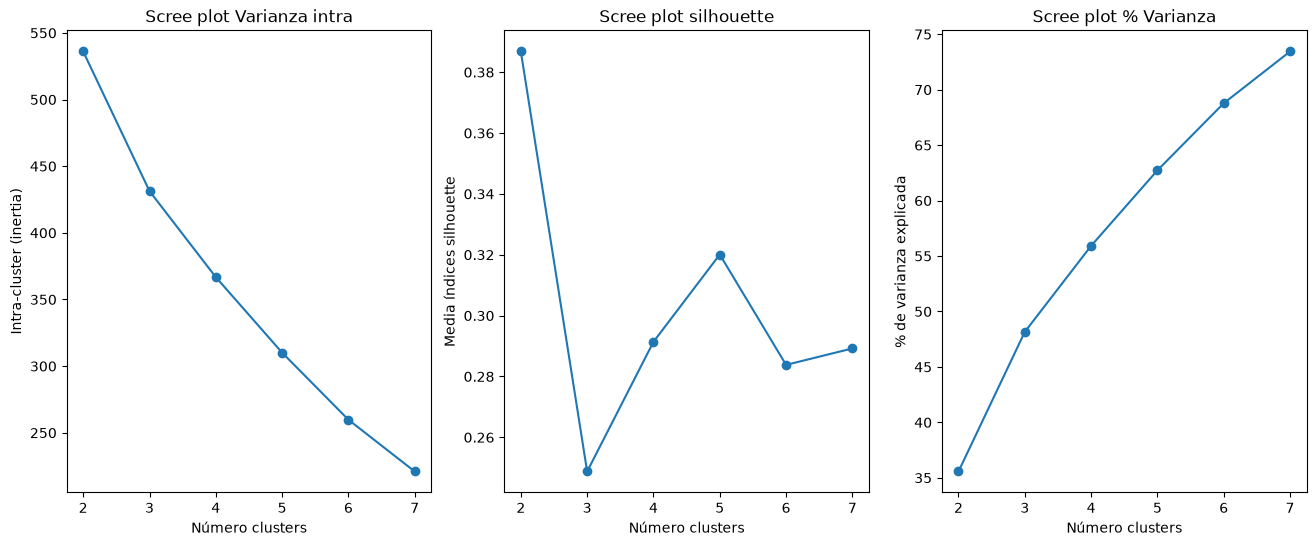

In [32]:
# Formula para revisar metricas
scree_plot_kmeans(X, n_max=8)

En el momento de elaboración del actual cuaderno, los valores idóneos se encuentran en k= 4/5, con valores de 0.30 y 0.33 respectivamente.

Recordemos que el umbral de la silueta debe mantenerse entre 0.20 y 0.40, con un % de varianza explicado alto.

Nos decantamos por seleccionar 4 clusters (k=4).

In [33]:
# Entrenamos K means con 4 clusters

kmeans = KMeans(n_clusters=4, random_state=42, n_init=20)
TurismoProvincia['cluster_saturacion'] = kmeans.fit_predict(X_scaled)

print(f"Silhouette Score final: {silhouette_score(X_scaled, TurismoProvincia['cluster_saturacion']):.3f}")# Visualizamos score

Silhouette Score final: 0.272


Un silhouette score de 0,272 es un valor suficiente para validar el resultado alcanzado

In [34]:
# Pequeño bucle for para revisar las provincias y el cluster que se les ha asignado

for cl in range(4):
    provs = TurismoProvincia[TurismoProvincia['cluster_saturacion'] == cl]['provincia'].tolist()
    print(f'-- CLUSTER {cl} ({len(provs)} provincias) ---')
    print(', '.join(provs))
    print(' ')

-- CLUSTER 0 (26 provincias) ---
Albacete, Ávila, Badajoz, Burgos, Cáceres, Ciudad Real, Córdoba, Cuenca, Guadalajara, Jaén, León, Lleida, La Rioja, Lugo, Ourense, Palencia, Salamanca, Segovia, Soria, Teruel, Toledo, Valladolid, Zamora, Zaragoza, Ceuta, Melilla
 
-- CLUSTER 1 (4 provincias) ---
Illes Balears, Málaga, Las Palmas, Santa Cruz de Tenerife
 
-- CLUSTER 2 (2 provincias) ---
Barcelona, Madrid
 
-- CLUSTER 3 (20 provincias) ---
Araba/Álava, Alacant/Alicante, Almería, Cádiz, Castelló/Castellón, A Coruña, Girona, Granada, Gipuzkoa, Huelva, Huesca, Murcia, Navarra, Asturias, Pontevedra, Cantabria, Sevilla, Tarragona, València/Valencia, Bizkaia
 


Tras la revisión de las provincias, se puede observar una clara diferencia en los cuatro clusters creados, por lo que se les dará un nombre a cada uno

In [35]:
Clusters = {0: 'Desaprovechado', #Albacete
            1: 'Hipersaturado', # Baleares
            2: 'Grandes metrópolis', # Madrid
            3: 'Destinos maduros' # Alicante
            }

#Asignamos el nombre del cluster
TurismoProvincia['saturacion'] = TurismoProvincia['cluster_saturacion'].map(Clusters).astype('category')

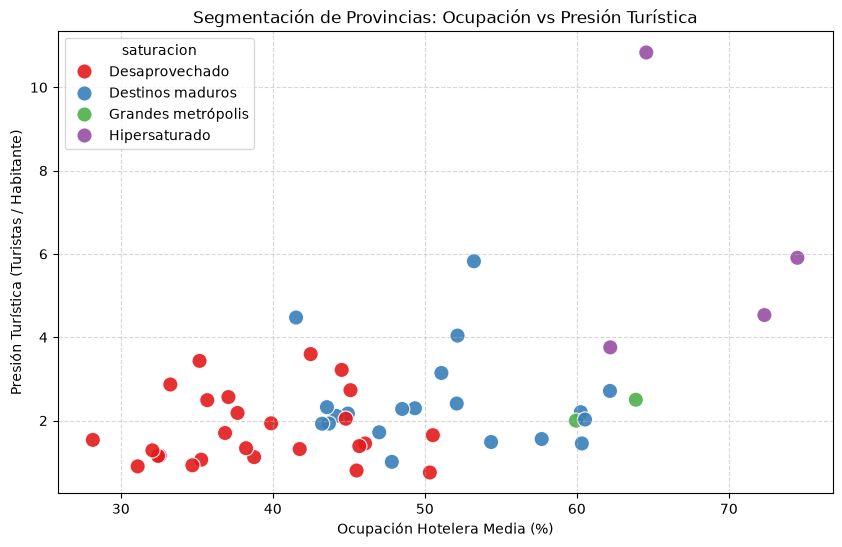

In [36]:
# Grafico de dispersion

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=TurismoProvincia,
    x='ocupacion_hotel_media',
    y='presion_turistica_hab',
    hue='saturacion',
    palette='Set1',
    s=120,
    alpha=0.9
)
plt.title('Segmentación de Provincias: Ocupación vs Presión Turística')
plt.xlabel('Ocupación Hotelera Media (%)')
plt.ylabel('Presión Turística (Turistas / Habitante)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Observando el gráfico de dispersión sobre ocupación hotelera es cierto que encontramos algunas "zonas grises", especialmente entre los destinos desaprovechados y maduros, y las grandes ciudades con los destinos maduros.

Aprovechando que es un GeoDataFrame, vamos a observar esta catalogación en un mapa de España.

**Objeto 1:** Mapa de España según cluster de saturación

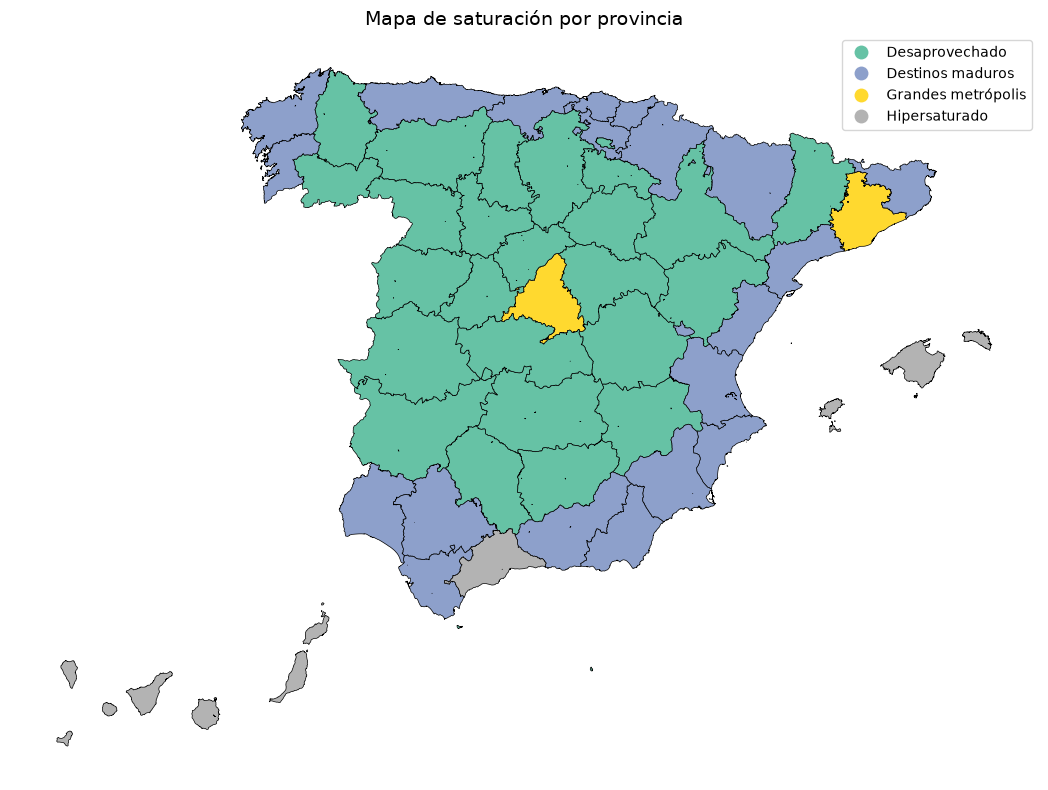

In [37]:
# Cruzamos los clusters con la cartografía provincial (mapa por provincias)
Map_prov.columns = Map_prov.columns.str.strip().str.lower()
mapa_clusters = Map_prov.merge(TurismoProvincia[['cod_prov', 'saturacion']], on='cod_prov', how='left')

# Definimos imagen
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
mapa_clusters.plot(
    column='saturacion',
    categorical=True,
    cmap='Set2',
    legend=True,
    linewidth=0.5,
    edgecolor='black',
    ax=ax,
)
ax.set_title('Mapa de saturación por provincia', fontsize=14)
ax.axis('off')
plt.tight_layout()
plt.show()

Este visual nos da una imagen mucho más clara de la división categórica:

* **0: Desaprovechados.** Destinos generalmente de interior peninsular sin movimientos turísticos importantes
* **1: Hipersaturados.** Destinos con un alto grado de ocupación, que se ve reflejado en el coste por habitación (``ADR``). principalmente archipielagos exceptuando Málaga.
* **2: Grandes metropolis.** Las dos grandes ciudades de España, con cualidades únicas, una tasa de ocupación alta acompañada de un nivel un gran margen de ocupación en temporadas valle.
* **3: Destinos maduros.** Destinos con acceso al mar (exceptuando Sevilla), con alta ocupación en temporada alta.

Tras comprobar el éxito de este primer cluster, vamos a desarrollar el segundo más centrado en el potencial de cada provincia

In [38]:
OfertaOSM.head()

categoria,cod_prov,provincia,alojamiento,cultura,ocio,restauracion,servicios turisticos,turismo general
0,01,Araba/Álava,136,137,165,1033,5,0
1,02,Albacete,202,90,146,649,0,0
2,03,Alicante/Alacant,727,430,498,5145,10,0
3,04,Almería,307,188,247,1388,7,0
4,05,Ávila,246,106,127,437,7,0


In [39]:
OfertaOSM.cod_prov.info()

<class 'pandas.Series'>
RangeIndex: 52 entries, 0 to 51
Series name: cod_prov
Non-Null Count  Dtype
--------------  -----
52 non-null     str  
dtypes: str(1)
memory usage: 659.0 bytes


## Cluster 2 Potencial turístico por provincia 

Para realizar el estudio del potencial turístico, vamos a basarnos en la información trbajada en ``OfertaOSM``, especialmente en las columnas de ocio cultura y restauracion.

Como el proceso es idéntico al cluster 1, se va a agilizar la elaboración, no sin mencionar que comenzaremos elaborando métricas dedicadas

In [40]:
#Unimos TurismoProvincia con las métricas territoriales del nuevo OfertaOSM
OfertaOSM['cod_prov'] = OfertaOSM['cod_prov'].astype('Int64')

TurismoPotencial = TurismoProvincia.merge(
    OfertaOSM[['cod_prov', 'cultura', 'ocio', 'restauracion']],
    on='cod_prov',
    how='left'
).fillna(0)

# 2. Construimos el DataFrame específico de Potencial
df_potencial = pd.DataFrame()
df_potencial['cod_prov'] = TurismoPotencial['cod_prov']
df_potencial['provincia'] = TurismoPotencial['provincia']

# Variables de capacidad y margen, seleccionadas tras varias pruebas con diferentes variables

# Capacidad rural (plazas * (1 - ocupacion))
df_potencial['capacidad_rural_libre'] = TurismoPotencial['plazas_rural_media'] * (1 - TurismoPotencial['ocupacion_rural_media'] / 100.0)

# Capacidad hotel (plazas * (1- ocupacion))
df_potencial['margen_hotel_valle'] = TurismoPotencial['plazas_hotel_media'] * (1 - TurismoPotencial['ocupacion_hotel_media'] / 100.0)

# Duracion estancia
df_potencial['estancia_media_rural'] = TurismoPotencial['estancia_media_rural']



# Variables de OSM en escala logarítmica (tras varias pruebas, se ha decidido que es lo más acertado)
# Sumamos Cultura y Ocio como activos de atracción global (equivalente a atracciones + museos de toda la provincia)
df_potencial['cultura_ocio_log'] = np.log1p(
    TurismoPotencial['cultura'] + TurismoPotencial['ocio'])

df_potencial['restauracion_log'] = np.log1p(TurismoPotencial['restauracion'])



# StandardScaler
X_pot = df_potencial.drop(columns=['cod_prov', 'provincia']) #Quitamos variables string

scaler_pot = StandardScaler()
X_pot_scaled = scaler_pot.fit_transform(X_pot)

X_pot_scaled = pd.DataFrame(X_pot_scaled, columns=X_pot.columns, index=df_potencial['provincia'])

# Revisamos
X_pot_scaled.head()

,capacidad_rural_libre,margen_hotel_valle,estancia_media_rural,cultura_ocio_log,restauracion_log
provincia,,,,,
Araba/Álava,-0.967232,-0.692178,0.128680,-0.761808,-0.138130
Albacete,0.956350,-0.583900,0.502311,-1.074079,-0.550549
Alacant/Alicante,-0.651350,1.149481,-0.041152,0.662281,1.287586
Almería,-0.771367,0.195917,0.094714,-0.299250,0.124085
Ávila,1.211463,-0.652583,-0.041152,-1.090271,-0.901254


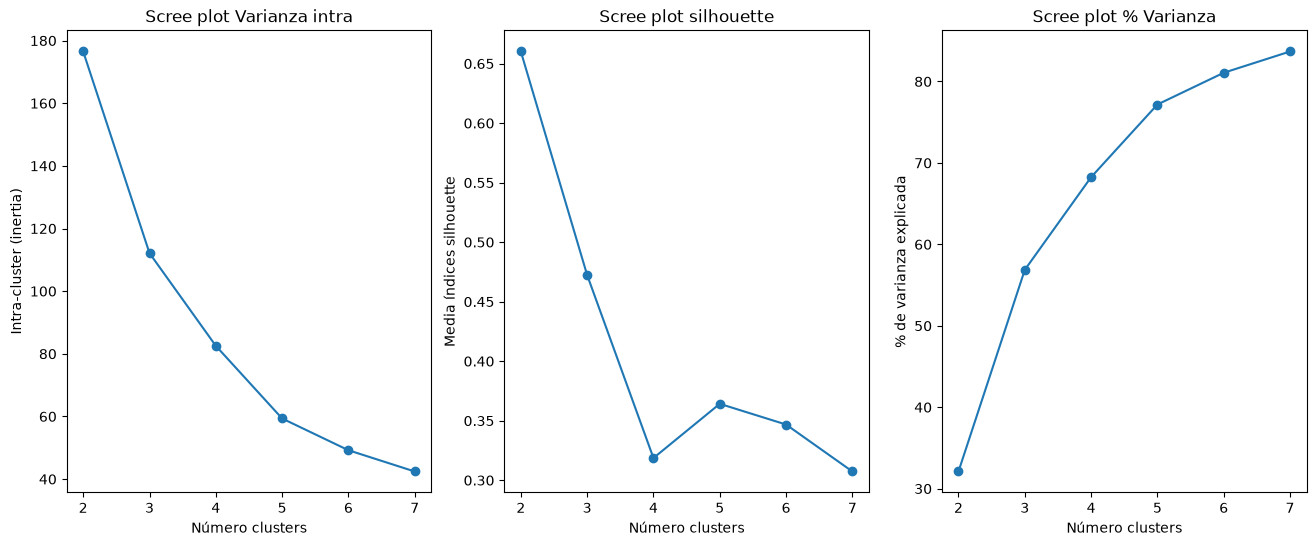

In [41]:
# Evaluamos el número óptimo de clusters para la dimensión de Potencial
scree_plot_kmeans(X_pot_scaled, n_max=8)

El nivel óptimo vuelve a ser 4/5 cluusters, ya que se situa en valores entre 0,2 y 0,4

In [42]:
# Repetimos con k=4
kmeans_pot = KMeans(n_clusters=4, random_state=42, n_init=20)
df_potencial['cluster_potencial'] = kmeans_pot.fit_predict(X_pot_scaled)

#Silhouette score
sil_pot = silhouette_score(X_pot_scaled, df_potencial['cluster_potencial'])
print(f"Silhouette Score final (Cluster Potencial k=4): {sil_pot:.3f}\n")


# Bucle para explorar visualmente el potencial de las provincias
for cl in sorted(df_potencial['cluster_potencial'].unique()):
    provs = df_potencial[df_potencial['cluster_potencial'] == cl]['provincia'].tolist()
    print(f"--- CLUSTER {cl}: ({len(provs)} provincias) ---")
    print(", ".join(provs))
    print(" ")

Silhouette Score final (Cluster Potencial k=4): 0.319

--- CLUSTER 0: (23 provincias) ---
Araba/Álava, Albacete, Ávila, Badajoz, Cáceres, Ciudad Real, Córdoba, Cuenca, Guadalajara, Huelva, Jaén, León, La Rioja, Lugo, Ourense, Palencia, Salamanca, Segovia, Soria, Teruel, Toledo, Valladolid, Zamora
 
--- CLUSTER 1: (6 provincias) ---
Illes Balears, Barcelona, Girona, Madrid, Málaga, Asturias
 
--- CLUSTER 2: (21 provincias) ---
Alacant/Alicante, Almería, Burgos, Cádiz, Castelló/Castellón, A Coruña, Granada, Gipuzkoa, Huesca, Lleida, Murcia, Navarra, Las Palmas, Pontevedra, Santa Cruz de Tenerife, Cantabria, Sevilla, Tarragona, València/Valencia, Bizkaia, Zaragoza
 
--- CLUSTER 3: (2 provincias) ---
Ceuta, Melilla
 


Creamos un diccionario para etiquetar cada cluster tras la exploración visual

In [43]:
# Diccionaro para asignar cluster
NombresPotencial = {
    0: 'Potencial bajo', #Albacete
    1: 'Destinos estrella', # Baleares, Madrid, Asturias
    2: 'Potencial alto', # Coruña
    3: 'Ciudades pequeñas' #Ceuta y Melilla
}

#Aplicamos
df_potencial['potencial'] = df_potencial['cluster_potencial'].map(NombresPotencial).astype('category')

Por último, añadimos los clusters al dataframe principal

In [44]:
TurismoProvincia['cluster_potencial'] = df_potencial['cluster_potencial']
TurismoProvincia['potencial'] = df_potencial['potencial']

**Objeto 2** Mapa de potencial turístico por provincia

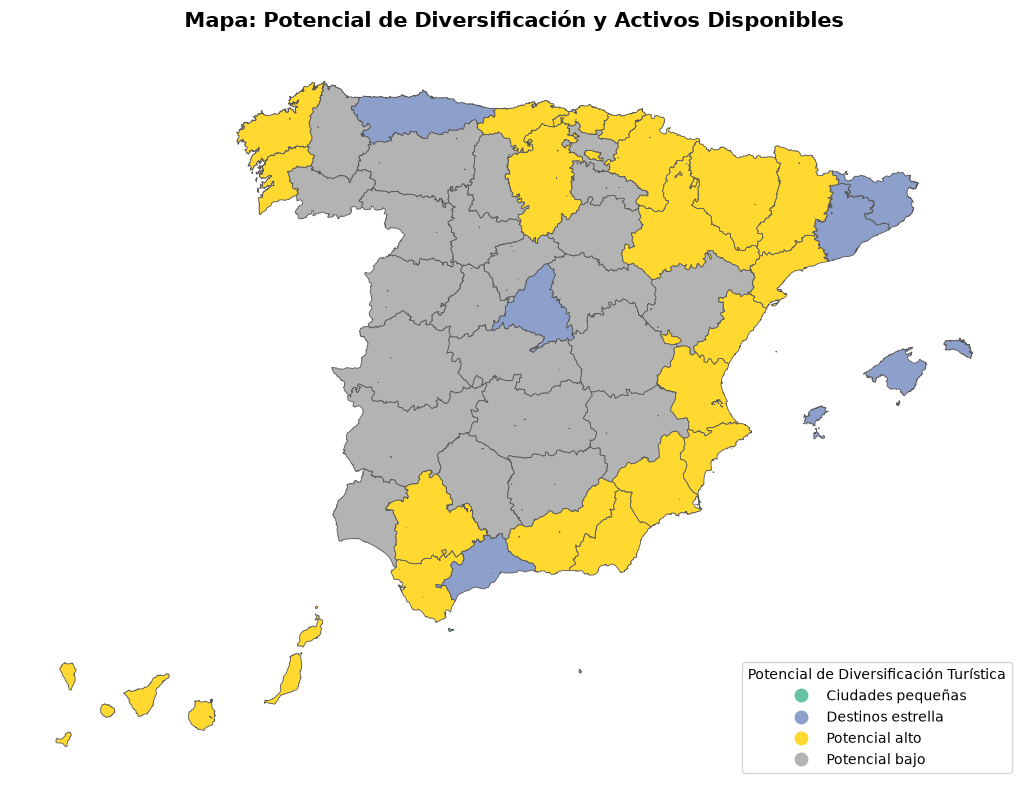

In [45]:
# Cruzamos el cluster de potencial con la cartografía provincial
mapa_potencial = Map_prov.merge(TurismoProvincia[['cod_prov', 'potencial']], on='cod_prov', how='left')

fig, ax = plt.subplots(1, 1, figsize=(13, 8))
mapa_potencial.plot(
    column='potencial',
    categorical=True,
    legend=True,
    cmap='Set2',
    edgecolor='0.35',
    linewidth=0.6,
    ax=ax,
    legend_kwds={
        'loc': 'lower right',
        'title': "Potencial de Diversificación Turística",
        'frameon': True
    }
)

ax.set_title("Mapa: Potencial de Diversificación y Activos Disponibles", fontsize=15, weight='bold', pad=15)
ax.axis('off')
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

**Objeto 3:** Matriz de decisión; provincias según su saturación y potencial

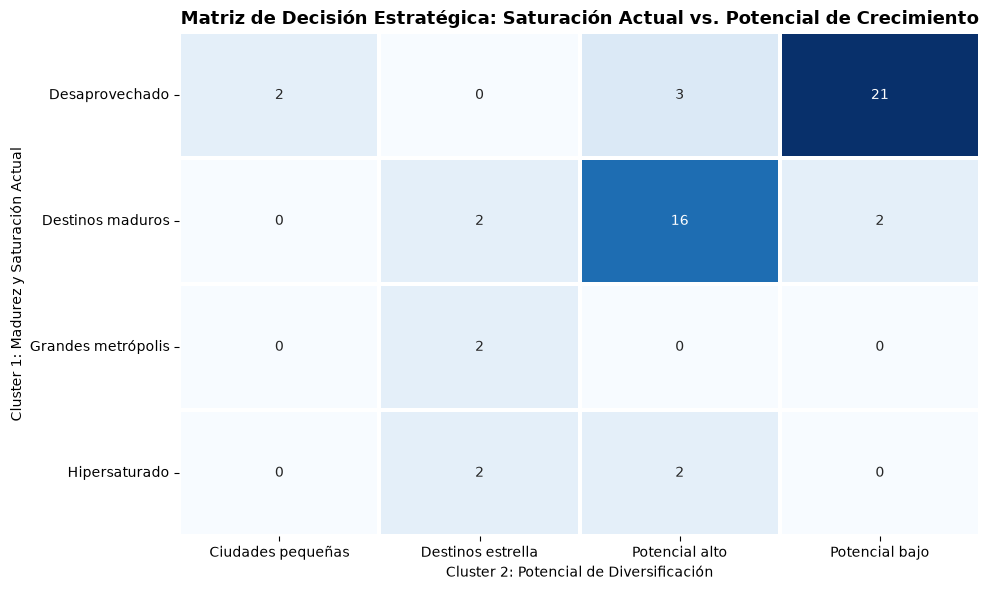

JOYAS OCULTAS PRIORITARIAS (Baja Saturación + Alto Potencial Cultural/Rural):



In [46]:
# Matriz de contingencia: Saturación actual vs Potencial de activos
matriz_cruce = pd.crosstab(
    TurismoProvincia['saturacion'], 
    TurismoProvincia['potencial'], 
    margins=True, 
    margins_name="Total"
)

plt.figure(figsize=(10, 6))
sns.heatmap(
    pd.crosstab(TurismoProvincia['saturacion'], TurismoProvincia['potencial']),
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    linewidths=1.5
)
plt.title("Matriz de Decisión Estratégica: Saturación Actual vs. Potencial de Crecimiento", fontsize=13, weight='bold')
plt.xlabel("Cluster 2: Potencial de Diversificación")
plt.ylabel("Cluster 1: Madurez y Saturación Actual")
plt.tight_layout()
plt.show()

# Extraer automáticamente las 'Joyas Ocultas'
joyas_ocultas = TurismoProvincia[
    (TurismoProvincia['saturacion'] == 'Desaprovechado') & 
    (TurismoProvincia['potencial'] == 'Gran potencial')
]['provincia'].tolist()

print("JOYAS OCULTAS PRIORITARIAS (Baja Saturación + Alto Potencial Cultural/Rural):")
print(", ".join(joyas_ocultas))

## Exploración y graficación

**Objeto 4** ADR por provincia según su cluster de saturación

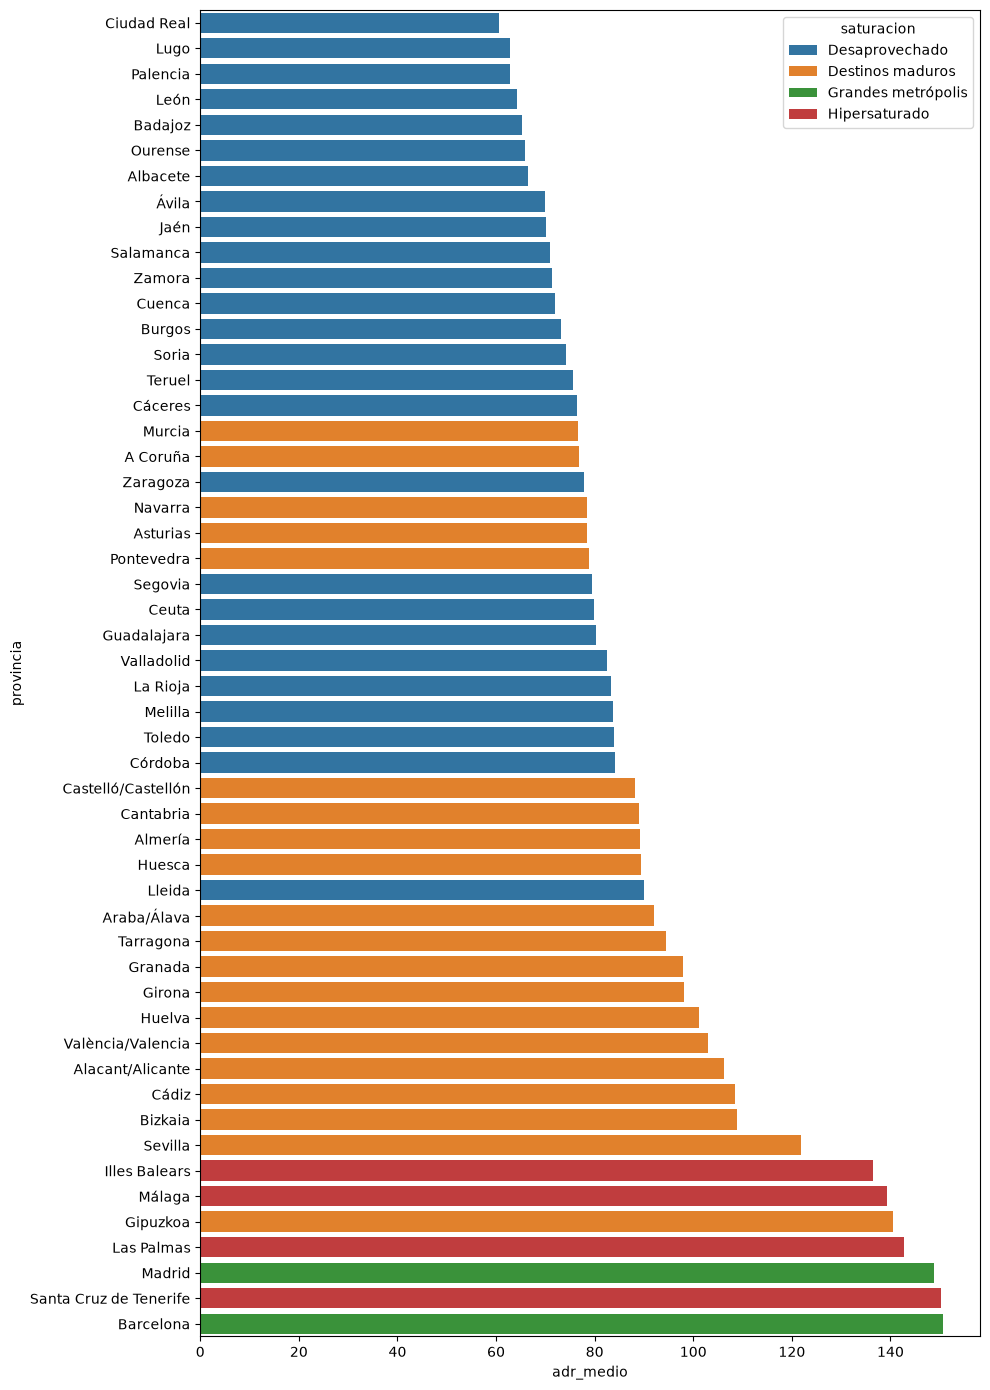

In [47]:
plt.figure(figsize=(10, 14)) #Mas largo para visualizar correctamente cada provincia
sns.barplot(data=TurismoProvincia.sort_values(by='adr_medio'), y='provincia', hue='saturacion', x='adr_medio', dodge=False )
plt.tight_layout()
plt.show()

In [48]:
OfertaOSM.head()

categoria,cod_prov,provincia,alojamiento,cultura,ocio,restauracion,servicios turisticos,turismo general
0,1,Araba/Álava,136,137,165,1033,5,0
1,2,Albacete,202,90,146,649,0,0
2,3,Alicante/Alacant,727,430,498,5145,10,0
3,4,Almería,307,188,247,1388,7,0
4,5,Ávila,246,106,127,437,7,0


**Objeto 5** Mapa de alojamientos de España

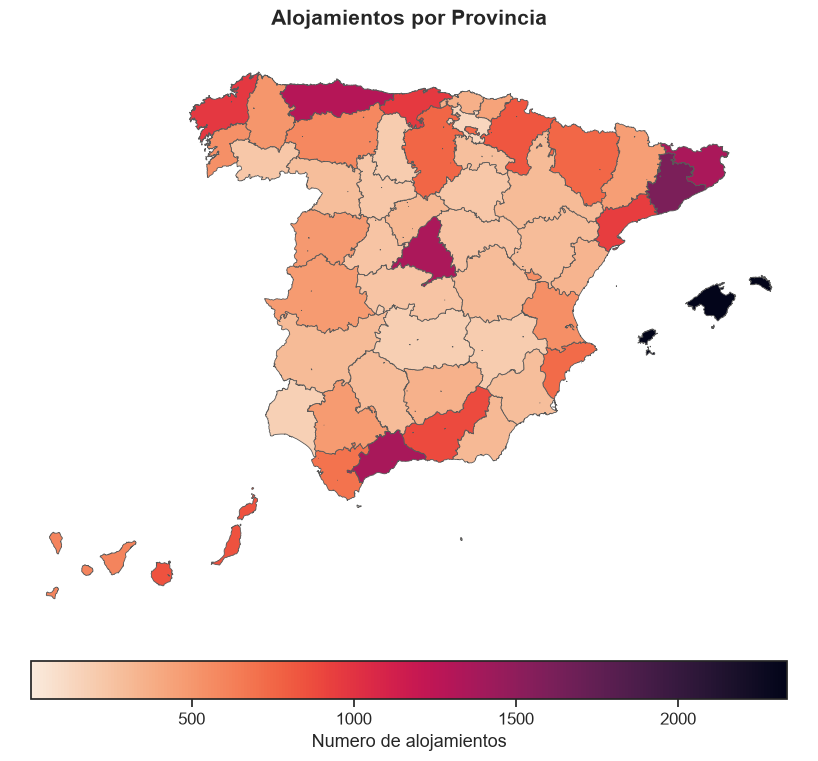

In [49]:

# 1. Configurar la estética general con Seaborn
sns.set_theme(style="white", font_scale=1.1)

# 2. Cargar cartografía y preparar las 52 provincias
gdf_muni = gpd.read_file('cartografias/Munic04_ESP.shp')
gdf_muni['COD_PROV'] = gdf_muni['COD_PROV'].astype(int)
gdf_provincias = gdf_muni.dissolve(by='COD_PROV', as_index=False)

# 3. Unir con las métricas provinciales
gdf_prov_analisis = gdf_provincias.merge(
    OfertaOSM[['cod_prov', 'alojamiento']],
    left_on='COD_PROV', 
    right_on='cod_prov', 
    how='inner'
)

# 4. Crear mapa de color continuo nativo de Seaborn (ej: 'rocket_r', 'flare' o 'mako_r')
cmap_seaborn = sns.color_palette("rocket_r", as_cmap=True)

# 5. Representación gráfica
fig, ax = plt.subplots(1, 1, figsize=(13, 8))

# Pintamos el mapa coroplético con el colormap de Seaborn
gdf_prov_analisis.plot(
    column='alojamiento',
    cmap=cmap_seaborn,
    legend=True,
    edgecolor='0.35',
    linewidth=0.6,
    ax=ax,
    legend_kwds={
        'label': "Numero de alojamientos",
        'orientation': "horizontal",
        'shrink': 0.6,
        'pad': 0.05
    }
)

# Título y ajustes con estilo Seaborn
ax.set_title("Alojamientos por Provincia", fontsize=15, weight='bold', pad=15)
ax.axis('off')
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

## Guardado de dataframes con creados, en un unico dataframe 

In [50]:
carpeta = Path('Datos procesados/Datos pulidos')
carpeta.mkdir(parents=True, exist_ok=True) # Por si no existe, se crea la carpeta


TurismoProvincia.to_csv(carpeta  / 'TurismoProvincia.csv', index=False, sep=';', encoding='UTF-8')

In [51]:
from dashboard.ai_service import TuiTourismAI
from IPython.display import display, Markdown

# Inicializamos el motor de IA
ai = TuiTourismAI()

# Ejemplo de datos de una provincia (puedes pasarle cualquier fila de TurismoProvincia)
datos_segovia = {
    "provincia": "Segovia",
    "cod_prov": "40",
    "cuadrante": "Oportunidad de Diversificación (Alto Potencial, Baja Saturación)",
    "viajeros_total": 450000,
    "ocupacion_hotel_media": 43.1,
    "margen_hotel_valle": 4500,
    "capacidad_rural_libre": 1200,
    "cultura_y_patrimonio": 364,
    "ocio_y_naturaleza": 359,
    "restauracion": 526,
    "total_poi_osm": 1572
}

fila_toledo = TurismoProvincia.loc[
    TurismoProvincia['provincia'].eq('Asturias')
].iloc[0].to_dict()

# Generamos el dictamen y lo mostramos maquetado en Markdown
dictamen = ai.generar_diagnostico_provincial(
    fila_toledo)

display(Markdown(dictamen))

Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


*(Dictamen generado en tiempo real con gemini-3.5-flash-lite)*

# DICTAMEN EJECUTIVO: ESTRATEGIA DE DIVERSIFICACIÓN Y DESESTACIONALIZACIÓN TURÍSTICA
**Para:** Comité de Dirección de TUI Group  
**De:** Director de Estrategia y Sostenibilidad Turística para España  
**Destino Analizado:** Provincia de Asturias (Código INE: 33)  
**Fecha:** Octubre 2023  

---

### 1. Diagnóstico Estratégico

El análisis del modelo bi-dimensional sitúa a Asturias en el cuadrante de **Saturación Media** en cuanto a presión demográfica/turística y un **Potencial Medio** en recursos y capacidad. Sin embargo, los datos operativos oficiales del INE y los registros georreferenciados revelan una disfunción estructural crítica que requiere intervención inmediata:

*   **Contraste entre Ocupación y Estacionalidad:** Aunque el volumen de absorción en los registros agregados muestra un grado de ocupación hotelera media del **43.7%** durante el período de valle, la estancia media se sitúa en unos frágiles **1.96 días**. Esto confirma un modelo de escapada corta de fin de semana, altamente ineficiente desde el punto de vista logístico y de rentabilidad por plaza.
*   **Margen de Absorción Real:** La saturación estival contrasta con un valle hibernal donde el colchón de plazas libres hoteleras y de turismo rural no está siendo capturado por los canales de TUI. Esto indica una falta de paquetización específica para los meses de menor afluencia, lo que genera una alta dependencia del turismo nacional de sol y montaña en julio y agosto.
*   **Riesgo de Gestión:** La "Saturación Media" no debe interpretarse como un aval para el crecimiento masivo. Las infraestructuras de acceso a los principales valles asturianos sufren cuellos de botella estacionales. El crecimiento futuro de TUI en este destino debe basarse estrictamente en valor añadido y dispersión territorial, nunca en incremento de volumen puro.

### 2. Potencial de Activos Ocultos

A pesar de que los datos brutos de OpenStreetMap volcados en el informe muestran un desfase técnico en la cuantificación masiva de POIs, el conocimiento experto del territorio y el inventario georreferenciado de TUI permiten identificar los activos subestimados por el turismo de masas:

*   **Patrimonio Industrial y Siderúrgico (Las Cuencas):** El legado de la minería del carbón y la siderurgia en las comarcas del Caudal y el Nalón representa un activo de turismo industrial de clase mundial (Ecomuniero de Mieres, Pozo San Fernando) completamente ignorado por los tour operadores generalistas.
*   **Red de Caminería Histórica y Vías Verdes:** Más allá del Camino de Santiago primitivo y costero, existe una red descongestionada de sendas verdes (antiguas cajas de ferrocarril minero) ideales para el cicloturismo de media y baja intensidad.
*   **Paisaje Cultural Protegido (Parques Naturales de Redes y Somiedo):** Recursos de biodiversidad (oso pardo, urogallo) y arquitectura tradicional (teitos y hórreos) con un potencial inigualable para el ecoturismo de observación, el cual sufre una baja valorización comercial en los canales tradicionales de venta.

### 3. Propuesta de Producto TUI

Para capturar la demanda europea sénior y eco-consciente en temporada baja, diseñamos el siguiente paquete estratégico:

*   **Nombre Comercial:** *Asturias Sostenible: Slow Driving, Industrial Heritage & Biosphere*
*   **Público Objetivo:** Mercado internacional (Reino Unido, Alemania y Países Nórdicos). Perfil *Senior Active* y parejas de 45-70 años con poder adquisitivo medio-alto, interesados en la gastronomía, el patrimonio industrial y la naturaleza sin masificación.
*   **Meses Recomendados:** Octubre a mayo (excluyendo festivos navideños puntuales), incidiendo especialmente en los meses valles de noviembre, febrero y marzo.
*   **3 Experiencias Clave:**
    1.  *Ruta del Patrimonio Vivo:* Inmersión guiada en el Valle de Langreo y Mieres con antiguos mineros, combinada con cata de sidra de Denominación de Origen Protegida (DOP) en llagares tradicionales alejados de los circuitos convencionales.
    2.  *Ecodescubrimiento en Somiedo:* Jornada de avistamiento de fauna y flora con guías locales certificados por el Parque Natural, incluyendo pernoctación en alojamientos rurales certificados con etiqueta ecológica de TUI.
    3.  *Gastronomía de Alta Raíz:* Talleres culinarios privados de cocina asturiana de vanguardia y producto de kilómetro cero, vinculados a la red de *Meses del Gochu Asturcón* o jornadas de la caza.

### 4. Plan de Desestacionalización e Impacto

Para garantizar que la operativa de TUI en Asturias cumpla con los estándares de sostenibilidad y rentabilidad del grupo, se establecen los siguientes objetivos cuantitativos y medidas de mitigación:

*   **Objetivos Cuantitativos (Horizonte 24 meses):**
    *   **Aumento de la ocupación en valle:** Elevar la ocupación hotelera media de la temporada baja asturiana del **43.7% al 58%** en los establecimientos asociados a TUI.
    *   **Incremento de la estancia media:** Ampliar la pernoctación actual de 1.96 días a un mínimo de **4.2 días** mediante la paquetización de rutas circulares de baja densidad.
    *   **Diversificación geográfica:** Lograr que el 65% de las pernoctaciones gestionadas por TUI se produzcan fuera de los focos tradicionales (Oviedo, Gijón y los Picos de Europa), canalizándolas hacia el centro y occidente de la región.
*   **Mitigación de la Huella y Sostenibilidad:**
    *   **Movilidad eléctrica:** Incorporación obligatoria de vehículos eléctricos o híbridos en los paquetes de *fly-drive* y *slow driving* comercializados por TUI.
    *   **Certificación de Proveedores:** Exigir que el 100% de